In [2]:
# Set up sys.path so that 'src/spindle_dev' is importable as 'spindle_dev'
import sys
import importlib
from pathlib import Path

project_root = '/data/sarkar_lab/Projects/spindle_dev'
src_path = Path(project_root) / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import spindle_dev
# Reload to pick up code changes without restarting the kernel
importlib.reload(spindle_dev)

<module 'spindle_dev' from '/data/sarkar_lab/Projects/spindle_dev/src/spindle_dev/__init__.py'>

In [3]:
import scanpy as sc

In [4]:
import glob

In [5]:
h5ad_files = glob.glob("/data/sarkar_lab/insitupy_demo_data_xenium/*.h5ad")

In [6]:
h5ad_files

['/data/sarkar_lab/insitupy_demo_data_xenium/xenium_human_skin_melanoma.h5ad',
 '/data/sarkar_lab/insitupy_demo_data_xenium/xenium_human_brain_cancer.h5ad',
 '/data/sarkar_lab/insitupy_demo_data_xenium/xenium_human_kidney_nondiseased.h5ad',
 '/data/sarkar_lab/insitupy_demo_data_xenium/xenium_human_lung_cancer.h5ad',
 '/data/sarkar_lab/insitupy_demo_data_xenium/xenium_human_lymph_node.h5ad',
 '/data/sarkar_lab/insitupy_demo_data_xenium/xenium_human_lymph_node_5k.h5ad',
 '/data/sarkar_lab/insitupy_demo_data_xenium/xenium_human_pancreatic_cancer.h5ad',
 '/data/sarkar_lab/insitupy_demo_data_xenium/xenium_human_breast_cancer.h5ad']

In [9]:
adata = sc.read_h5ad('/data/sarkar_lab/insitupy_demo_data_xenium/xenium_human_brain_cancer.h5ad')

In [10]:
from pathlib import Path
import spindle_dev
import spindle_dev.metrics as metrics
import spindle_dev.index as index
import spindle_dev.preprocessing as preprocessing
import spindle_dev.plotting as plotting
import spindle_dev.test as test
import spindle_dev.search as search
import spindle_dev.typing as typing
# Reload to pick up code changes without restarting the kernel

import time
import scanpy as sc
import glob
import pandas as pd
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from joblib import Parallel, delayed
import argparse

In [11]:
result_dir = "/data/sarkar_lab/Projects/spindle_dev/results/hbrain_10X/"
Path(result_dir).mkdir(parents=True, exist_ok=True)

In [12]:
all_genes = True
resolution=0.5
min_final_size=10

start_time = time.time()

coords = adata.obsm["spatial"]
tiles = preprocessing.build_quadtree_tiles(coords, max_pts=200, min_side=0.0, max_depth=40)
# remove tiles with less than 5 spots
tiles = [tile for tile in tiles if len(tile.idx) >= 5]
tiles = preprocessing.reindex_tiles(tiles)

num_genes = adata.n_vars

genes_work, gene_idx = spindle_dev.preprocessing.topvar_genes(adata, G=num_genes)  
tile_covs = spindle_dev.preprocessing.build_tile_covs_full_serial(adata, tiles, gene_idx, eps=1e-6)
data = index.ProcessedData(tiles, tile_covs, genes_work, adata.n_obs)
if 'pca' not in data.latent:
    data.reduce_dim(num_pca_components=30, n_components=2, do_umap=True)
data.cluster_spds(cluster_distance="tree", cluster_method="leiden", resolution=resolution)
data.assign_label_to_spots()
data.get_corr_mean_by_cluster()
out_dict = data.get_adaptive_runs(find_blocks=True, with_size_guard=True,min_final_size=min_final_size,max_final_size=100)
epsilon_block_wise_dict = {}
epsilon_dict = {}
for cluster_id in set(data.labels):
    eps_per_block, eps_elbow_per_block, eps = index.choose_adaptive_epsilons(data, cluster_id, k_target_per_block=64)
    epsilon_block_wise_dict[int(cluster_id)] = eps_elbow_per_block
    epsilon_dict[int(cluster_id)] = eps

[2026-01-21 04:07:10,827] INFO spindle_dev.index: Clustering SPD-s using 'tree' distance.
[2026-01-21 04:07:11,016] INFO spindle_dev.index: Building ultrametric features from SPD matrices.
/panfs/accrepfs.vampire/home/sarkah1/miniforge3/envs/spatial/lib/python3.10/site-packages/scipy/cluster/hierarchy.py:1673: RuntimeWarning: invalid value encountered in scalar divide
  c = xp.sum(numerator) / xp.sqrt(xp.sum(denomA) * xp.sum(denomB))
[2026-01-21 04:10:32,508] INFO spindle_dev.index: Computing latent features from the tree representations.
[2026-01-21 04:10:56,656] INFO spindle_dev.index: Reducing latent features to 30 dimensions using PCA.
[2026-01-21 04:11:42,621] INFO spindle_dev.index: Explained variance ratios by PCA components: [0.03411894 0.02578561 0.01285703 0.00938737 0.00588084 0.00551661
 0.00453925 0.00377464 0.00356478 0.00307318 0.00273169 0.0026462
 0.00263546 0.00248134 0.00241321 0.00210543 0.00208783 0.00205712
 0.0020324  0.00196088 0.00191746 0.00189922 0.00186625 0

In [13]:
import matplotlib.pylab as plt
from matplotlib.patches import Rectangle    
from matplotlib.collections import PatchCollection

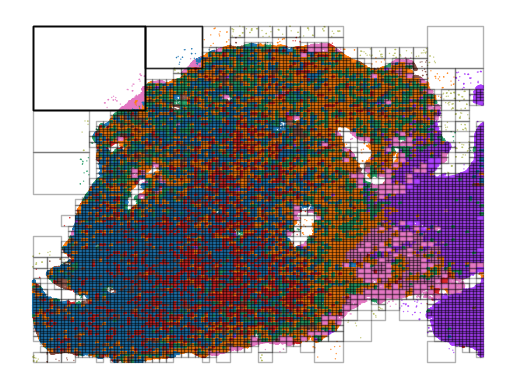

In [14]:
import numpy as np
palette = sc.pl.palettes.default_20
point_colors = [palette[lab] for lab in data.spot_label.values()]
labels = data.labels
indices = np.array([int(i) for i in data.spot_label.keys()])
coords = adata.obsm['spatial']
plt.scatter(coords[indices,0], coords[indices,1], s=1, c=point_colors, lw=0, alpha=0.8)
patches = []
for t in tiles:
    bbox = t.bbox if hasattr(t, "bbox") else t["bbox"]  # (xmin,ymin,xmax,ymax)
    x0, y0, x1, y1 = bbox
    patches.append(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False))
pc = PatchCollection(patches, match_original=True, linewidths=0.2, edgecolors='b', alpha=0.3)
# add collection
ax = plt.gca()
ax.add_collection(pc)
ax.invert_yaxis()
ax.axis('off')
#ax.set_aspect('equal')
plt.savefig(f"{result_dir}/spatial_plot_with_cluster.png", dpi=300)
plt.show()

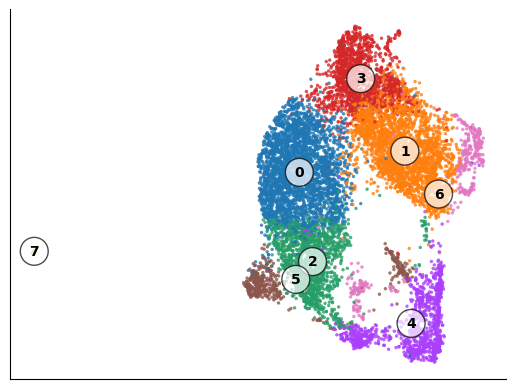

In [15]:
# Create colors for clusters
import numpy as np
import matplotlib.pyplot as plt
n_clusters = len(set(data.labels))
# Use Scanpy's default_20 palette for consistency
palette = sc.pl.palettes.default_20
cluster_colors = [palette[lab] for lab in data.labels]
plt.scatter(data.latent['umap'][:,0], data.latent['umap'][:,1], s=6, lw=0, alpha=0.8, c=cluster_colors)
# Write label on the plot
# with backgrond circle for better visibility
# and bold font
for i in range(n_clusters):
    cluster_points = data.latent['umap'][data.labels == i]
    if len(cluster_points) == 0:
        continue
    x_mean = np.mean(cluster_points[:,0])
    y_mean = np.mean(cluster_points[:,1])
    plt.text(x_mean, y_mean, str(i), color='black', fontsize=10, ha='center', va='center', fontweight='bold',
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='circle,pad=0.5', alpha=0.7))
# take away top and right border
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# remove axis ticks
ax.set_xticks([])
ax.set_yticks([])
plt.savefig(f"{result_dir}/umap_plot_with_cluster_labels.png", dpi=300)
plt.show()

In [16]:
epsilon_block_wise_dict = {}
epsilon_dict = {}
for cluster_id in set(data.labels):
    eps_per_block, eps_elbow_per_block, eps = index.choose_adaptive_epsilons(data, cluster_id, k_target_per_block=64)
    epsilon_block_wise_dict[int(cluster_id)] = eps_elbow_per_block
    epsilon_dict[int(cluster_id)] = eps

In [18]:
epsilon_dict

{0: np.float64(6.102528176453383),
 1: np.float64(7.198015254724661),
 2: np.float64(7.622794235690398),
 3: np.float64(7.687026962565294),
 4: np.float64(6.851659581044885),
 5: np.float64(6.414602220897768),
 6: np.float64(7.348541690464721),
 7: np.float64(1.8774843590512265)}

In [19]:
config = typing.IndexConfig()
config.epsilon_dict = epsilon_dict
config.epsilon_block_wise_dict = epsilon_block_wise_dict
config.threshold_type = 'constant' 
config.kmean_method = 'epsilon_net'

In [20]:
# Create index 
dag_dict, stat, dist_list = index.index_spds(data, config=config)

[2026-01-21 04:26:48,811] INFO spindle_dev.index: Processing cluster 0
[2026-01-21 04:26:48,813] INFO spindle_dev.index: Building SPD index with epsilon=6.102528176453383
[2026-01-21 04:26:48,817] INFO spindle_dev.index: Step 1: Cluster blocks within each class of SPD matrices.
[2026-01-21 04:26:49,859] INFO spindle_dev.index: Cluster 0: 3053 SPDs, 36 blocks
[2026-01-21 04:26:49,860] INFO spindle_dev.index:  Using epsilon-net clustering for block 0
[2026-01-21 04:26:50,083] INFO spindle_dev.index:  Finished block 0 in 0.22 seconds, found 2 clusters.
[2026-01-21 04:26:50,085] INFO spindle_dev.index:  Using epsilon-net clustering for block 1
[2026-01-21 04:26:50,445] INFO spindle_dev.index:  Finished block 1 in 0.36 seconds, found 6 clusters.
[2026-01-21 04:26:50,446] INFO spindle_dev.index:  Using epsilon-net clustering for block 2
[2026-01-21 04:26:50,736] INFO spindle_dev.index:  Finished block 2 in 0.29 seconds, found 4 clusters.
[2026-01-21 04:26:50,738] INFO spindle_dev.index:  Usi

In [21]:
search_cfg = search.SearchConfig(max_results=2, debug=False, max_failed_starts=5, max_failed_paths=10)

In [22]:
test_results = test.run_sanity_search(data, dag_dict, config, search_cfg, max_queries=2000, skip_baseline=True)

[2026-01-21 04:29:05,337] INFO spindle_dev.test: Built ground-truth paths for 3053 SPDs in cluster 0 across 36 blocks.
[2026-01-21 04:29:18,299] INFO spindle_dev.test: Built ground-truth paths for 2643 SPDs in cluster 1 across 36 blocks.
[2026-01-21 04:29:22,302] INFO spindle_dev.test: Built ground-truth paths for 1523 SPDs in cluster 2 across 35 blocks.
[2026-01-21 04:29:26,399] INFO spindle_dev.test: Built ground-truth paths for 1479 SPDs in cluster 3 across 38 blocks.
[2026-01-21 04:29:28,941] INFO spindle_dev.test: Built ground-truth paths for 1196 SPDs in cluster 4 across 39 blocks.
[2026-01-21 04:29:29,323] INFO spindle_dev.test: Built ground-truth paths for 460 SPDs in cluster 5 across 35 blocks.
[2026-01-21 04:29:29,650] INFO spindle_dev.test: Built ground-truth paths for 414 SPDs in cluster 6 across 38 blocks.
[2026-01-21 04:29:29,653] INFO spindle_dev.test: Built ground-truth paths for 34 SPDs in cluster 7 across 19 blocks.
[2026-01-21 04:29:29,653] INFO spindle_dev.test: Cre

KeyboardInterrupt: 

In [23]:
fig = plotting.visualize_block_dag_sankey_scaled(dag_dict[2].nodes, height=800, thickness=20.0)
fig

In [24]:
import pandas as pd
def get_dag_stats(dag_dict):
    dag_stats = []
    for cluster_id, cluster_dag in dag_dict.items():
        block_to_node = cluster_dag.block_to_node_indices
        for node in cluster_dag.nodes:
            
            num_spds = len(node.metadata.members)
            block_size = node.metadata.mean.shape[0]
            block_id = node.block_index
            radius = node.metadata.radius
            
            #print(f"Cluster_id {cluster_id} Node id {node.global_node_id} Block {block_id}: {num_spds} spds")
            dag_stats.append({
                "cluster_id": cluster_id,
                "node_id": node.global_node_id,
                "block_id": block_id,
                "block_cluster_id": node.block_cluster_id,
                "num_spds": num_spds,
                "radius": radius,
                "block_size": block_size
            })
    dag_stats_df = pd.DataFrame(dag_stats)
    return dag_stats_df

In [25]:
dag_stats_df = get_dag_stats(dag_dict)

In [26]:
score_list = []
for cluster_id in set(data.labels):
    cluster_dag = dag_dict[cluster_id]
    cluster_score = index.score_nodes_from_a_cluster(data, cluster_id, dag_dict, take_representative_mean=True)
    score_list.extend(cluster_score)

100%|██████████| 162/162 [00:00<00:00, 218.94it/s]


In [27]:
node_scores = []
for node_score in score_list:
    node_scores.append({
        "cluster_id": node_score["cluster_id"],
        "block_id": node_score["block_id"],
        "node_id": node_score["node_id"],
        "node_score": node_score["node_score"],
        "num_spds": node_score["num_spds"],
        "block_size": node_score["block_size"],
        "E": node_score["E"],
        "Q": node_score["Q"],
        "S": node_score["S"],
        "num_modules": len(node_score["modules"])
    })
node_score_df = pd.DataFrame(node_scores)


In [28]:
node_score_df.sort_values(by='node_score', ascending=False).head(20)

,cluster_id,block_id,node_id,node_score,num_spds,block_size,E,Q,S,num_modules
1296,6,35,109,0.358013,1,50,2.413795,0.246120,0.397371,4
1054,5,15,99,0.280287,14,15,1.063484,0.493565,0.466018,4
702,3,34,117,0.245047,1,49,2.530938,0.177834,0.455560,2
1297,6,35,110,0.230143,1,50,2.336212,0.171471,0.425498,4
1114,5,21,159,0.228424,4,40,1.072593,0.314746,0.323380,8
1294,6,35,107,0.223030,1,50,3.197471,0.181123,0.614894,4
424,1,25,83,0.220085,2,48,2.849021,0.169532,0.544341,4
1138,5,31,183,0.219983,1,48,2.301896,0.188482,0.492972,2
1299,6,36,112,0.219743,94,19,1.589406,0.277518,0.501819,3
453,1,35,112,0.218760,1,49,3.300771,0.164754,0.597734,2


In [33]:
importlib.reload(plotting)

<module 'spindle_dev.plotting' from '/data/sarkar_lab/Projects/spindle_dev/src/spindle_dev/plotting.py'>

Creating combined figure for cluster 6, node 109, block 35


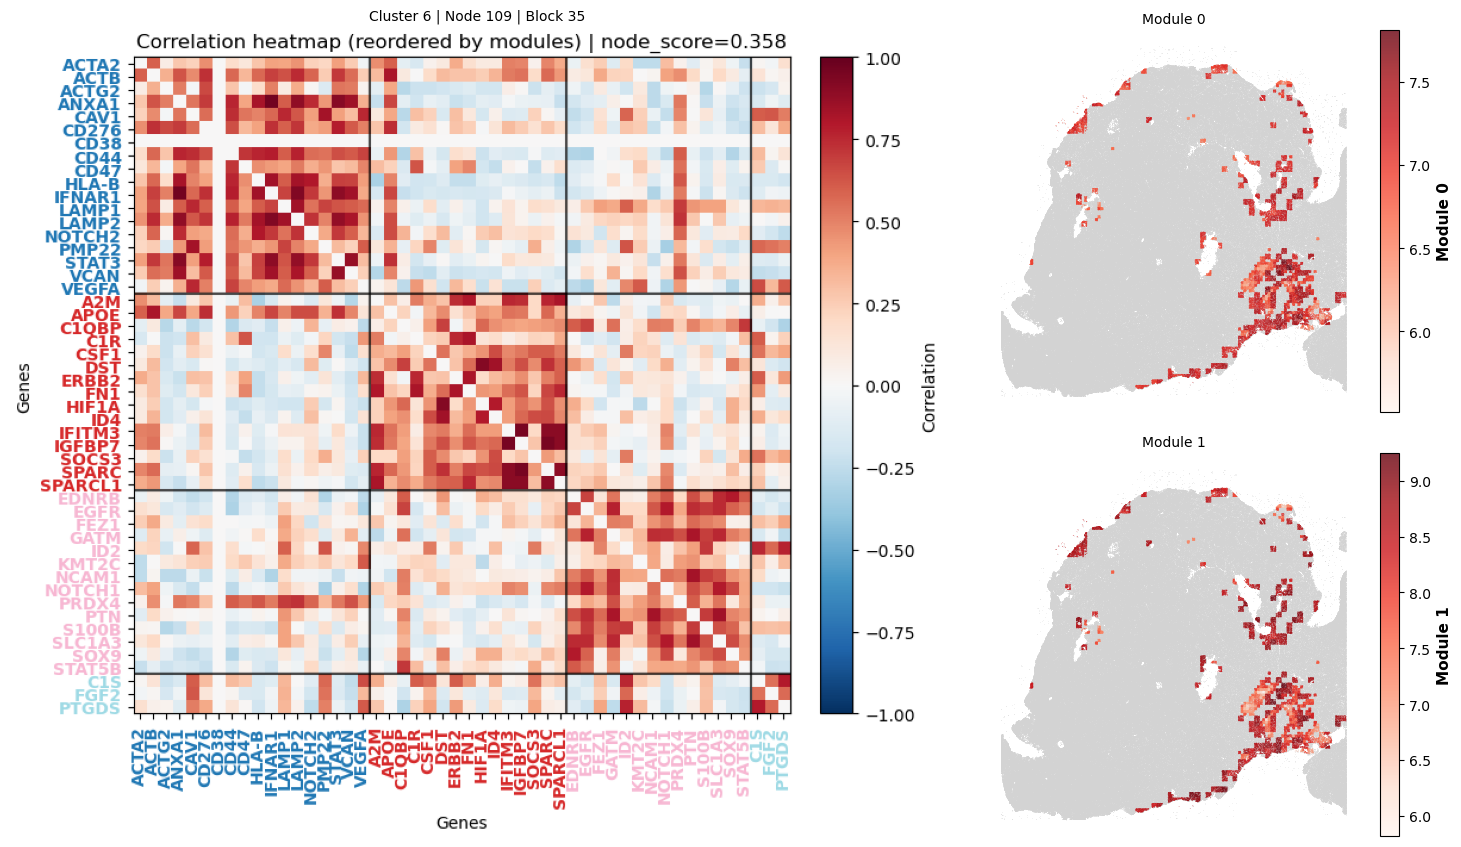

In [29]:
#id = 513
id = 1296
scores_846, fig_846 = plotting.plot_module_heatmap_plus_spatial(
    id,
    score_list,
    node_score_df,
    dag_stats_df,
    dag_dict,
    data,
    adata,
    spot_size=0.2
)

In [30]:

fig_846.savefig(f"{result_dir}/{id}_module_0_1_enrichment.png", dpi=300)

In [31]:
from spindle_dev import go_score

In [32]:
out_846 = go_score.enrich_modules_with_gseapy(score_list[id]['modules'])

  Module 0: enrichment completed with 946 terms
  Module 1: enrichment completed with 670 terms
  Module 2: enrichment completed with 791 terms
  Module 3: enrichment completed with 166 terms


In [124]:
importlib.reload(go_score)

<module 'spindle_dev.go_score' from '/data/sarkar_lab/Projects/spindle_dev/src/spindle_dev/go_score.py'>

['ACTA2', 'ACTB', 'ACTG2', 'ANXA1', 'CAV1', 'CD276', 'CD38', 'CD44', 'CD47', 'HLA-B', 'IFNAR1', 'LAMP1', 'LAMP2', 'NOTCH2', 'PMP22', 'STAT3', 'VCAN', 'VEGFA']


/data/sarkar_lab/Projects/spindle_dev/src/spindle_dev/go_score.py:519: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



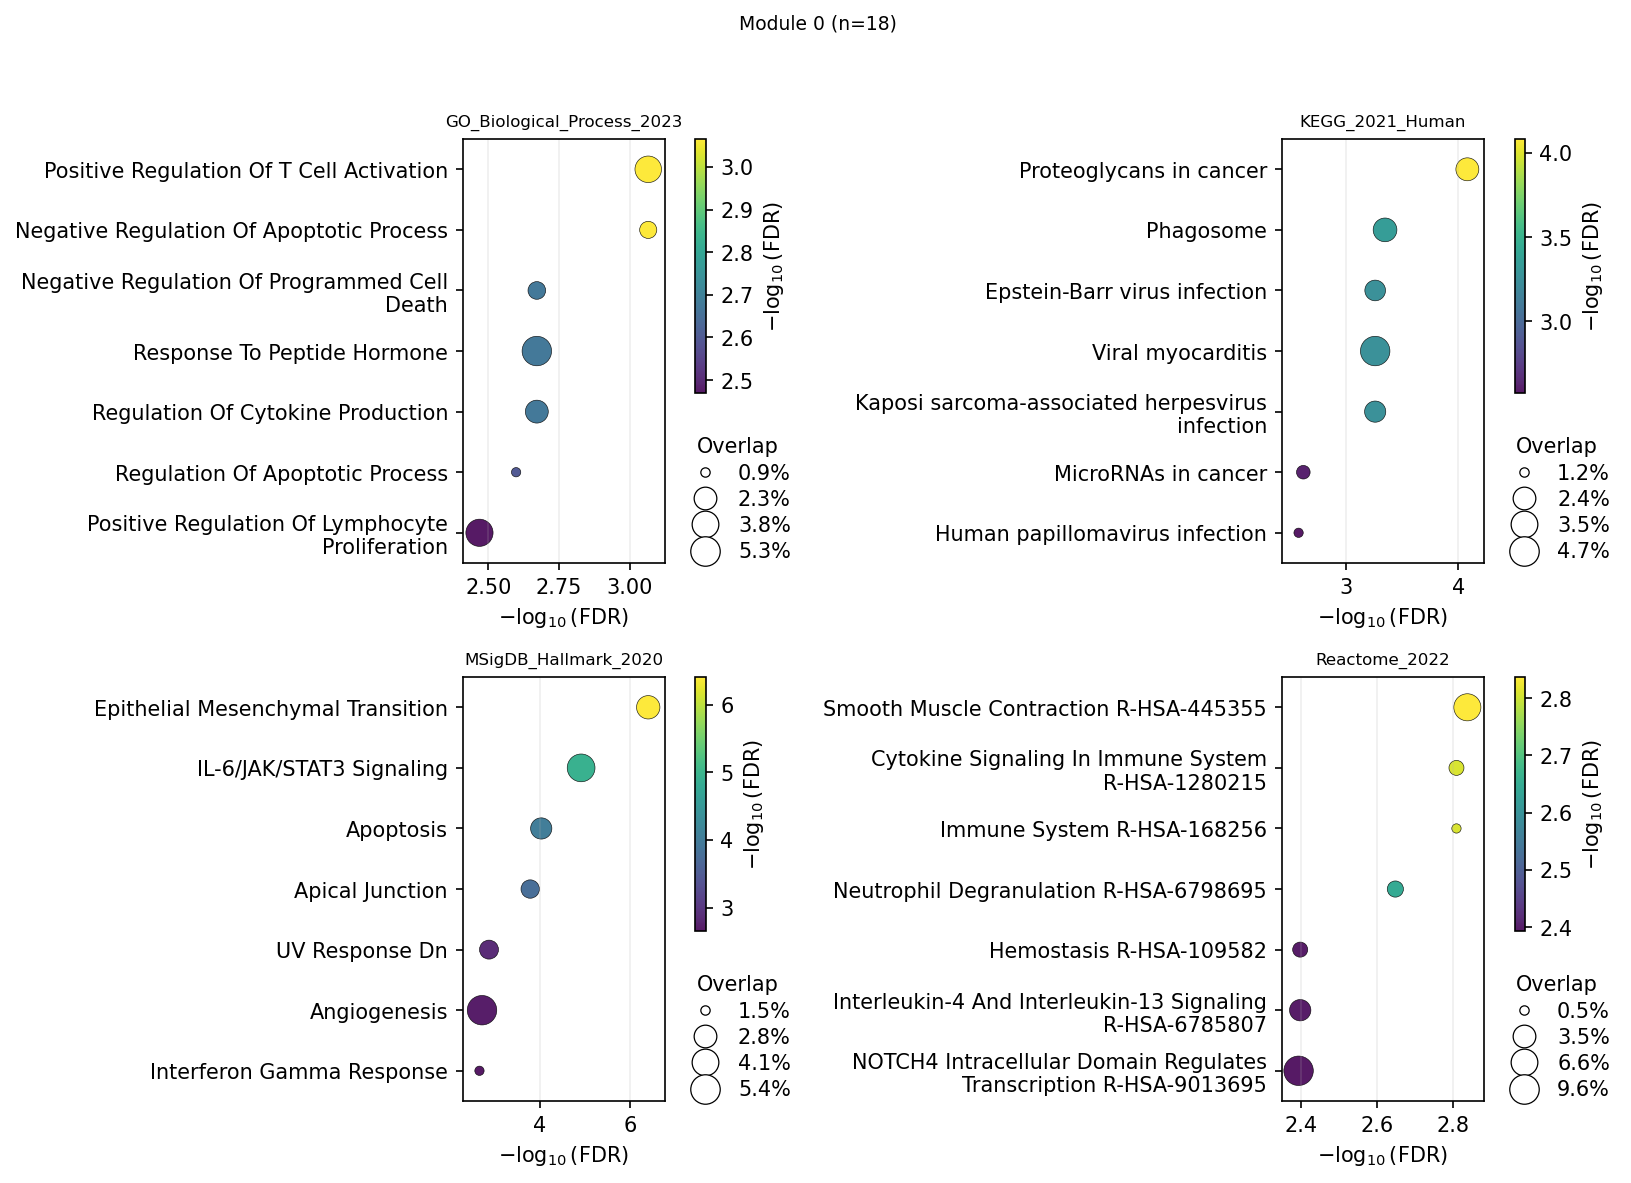

In [33]:
for module_id, module_genes, res in out_846:
    if module_id == 0:
        print(module_genes)
        fig, axes = go_score.plot_module_enrichment_libraries_2(
            module_id=module_id,
            module_genes=module_genes,
            res=res,
            top_n=7,
            ncols=2,
            bar_color="#D41515EE",   # pick your color
            tick_fontsize=10,
            label_fontsize=10,
            title_fontsize=8,
            compact_height_per_term=0.2,
            min_fig_h=8,
            plot_kind="dot",
            size_range=(20, 200),
            use_constrained_layout=False,
            save_dir=f"{result_dir}/go_enrichment/enrichment_{id}"
        )
        if fig is not None:
            plt.show()

In [39]:
# Create a dictionary of tile_id to block_id
# Clusters do not share tile ids across them
from collections import defaultdict
tile_to_block_dict = {}
cluster_to_tile = defaultdict(set)
for cluster_id, cluster_dag in dag_dict.items():
    block_to_node = cluster_dag.block_to_node_indices
    for node in cluster_dag.nodes:
        member_tile_ids = [tid for tid,_ in node.metadata.members]
        for tile_id in member_tile_ids:
            if not tile_id in tile_to_block_dict:
                tile_to_block_dict[tile_id] = {}
            tile_to_block_dict[tile_id][node.block_index] = node.block_cluster_id
            cluster_to_tile[cluster_id].add(tile_id)

In [40]:
def get_spot_score_dict(block_id, cluster_id, tile_to_block_dict, grid=False):
    spot_score = {}
    tiles_of_cluster = cluster_to_tile[cluster_id]
    for tid in tiles_of_cluster:
        if tid not in tile_to_block_dict:
            continue
        c = tile_to_block_dict[tid][block_id]
        t = data.metadata['tiles'][tid]
        for id in t.idx:
            spot_score[id] = c
    fig, ax = plotting.plot_spot_module_scores(spot_score, tiles, adata, color='discrete', grid=grid)
    return fig, ax

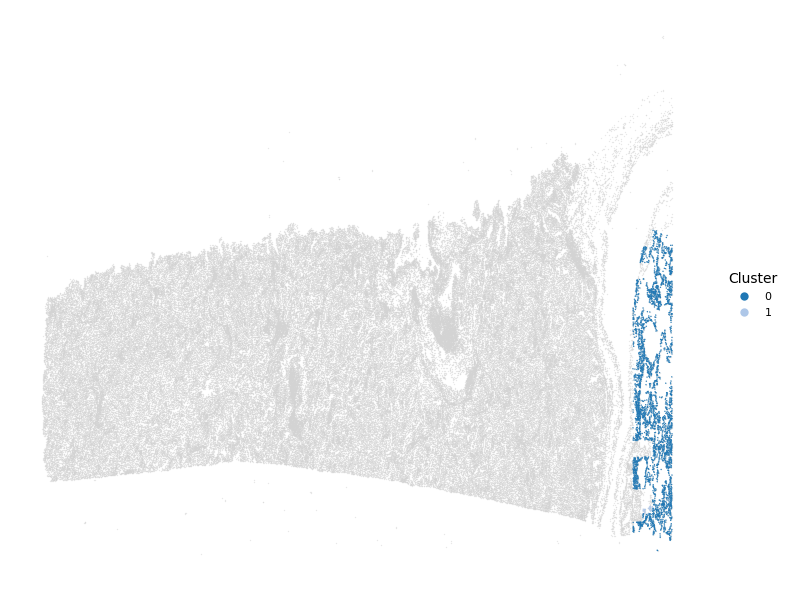

In [48]:
fig, ax = get_spot_score_dict(19, 4, tile_to_block_dict, grid=False)

/tmp/ipykernel_442280/2723282100.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata,color=['ARFGEF3'], spot_size=10, cmap='Reds')


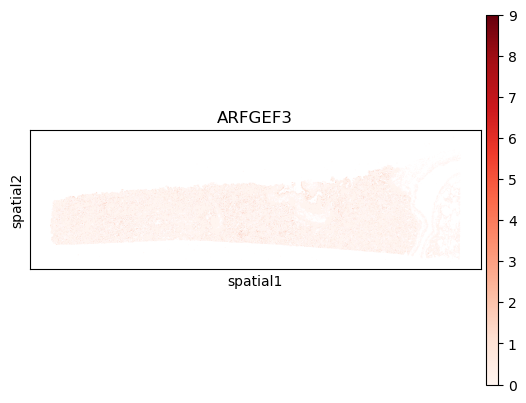

In [ ]:
sc.pl.spatial(adata,color=['ARFGEF3'], spot_size=20, cmap='Reds')

In [56]:
res.columns

Index(['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value',
       'Old P-value', 'Old Adjusted P-value', 'Odds Ratio', 'Combined Score',
       'Genes'],
      dtype='object')